### Import libraries and load the data

In [3]:
import pandas as pd
import numpy as np

# Load the raw dataset
df = pd.read_csv("hotel_bookings_data.csv")

print("Shape:", df.shape)
print(df.head())
print(df.info())                  

Shape: (119390, 29)
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2017          September   
1  Resort Hotel            0        737               2017          September   
2  Resort Hotel            0          7               2017          September   
3  Resort Hotel            0         13               2017          September   
4  Resort Hotel            0         14               2017          September   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_weekdays_nights  adults  ...  \
0                        0                         0       2  ...   
1     

### Check missing values properly

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print(missing_summary)

          missing_count  missing_pct
company          112593        94.31
agent             16340        13.69
city                488         0.41
children              4         0.00


### Fix missing values

In [5]:
# company / agent missing = booking wasn't made via a company/agent → 0 is a meaningful flag
df["company"] = df["company"].fillna(0)
df["agent"] = df["agent"].fillna(0)

# city missing = no location on file → keep the row, label it explicitly
df["city"] = df["city"].fillna("Unknown")

# children missing = assume 0 children (the safest, most common case)
df["children"] = df["children"].fillna(0)

# double-check
print(df.isnull().sum()[df.isnull().sum() > 0])   # should print nothing now

Series([], dtype: int64)


### Check for duplicate rows

In [6]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count} ({dup_count/len(df)*100:.1f}%)")

Duplicate rows: 33261 (27.9%)


### Fix inconsistent category values

In [7]:
print(df["meal"].value_counts())

meal
Breakfast     92310
Dinner        14463
No Meal       10650
Undefined      1169
Full Board      798
Name: count, dtype: int64


In [8]:
# "Undefined" meal = same real-world meaning as "No Meal" → merge them
df["meal"] = df["meal"].replace("Undefined", "No Meal")
print(df["meal"].value_counts())   # confirm "Undefined" is gone

meal
Breakfast     92310
Dinner        14463
No Meal       11819
Full Board      798
Name: count, dtype: int64


### Remove anomalies (invalid data, not just "weird" data)

In [9]:
# Look before you remove
print(df["adr"].describe())
print("adr <= 0:", (df["adr"] <= 0).sum())
print("adr > 1000:", (df["adr"] > 1000).sum())

# Zero-guest bookings
zero_guests = df[(df["adults"] == 0) & (df["children"] == 0) & (df["babies"] == 0)]
print("Zero-guest bookings:", len(zero_guests))

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64
adr <= 0: 1960
adr > 1000: 1
Zero-guest bookings: 180


In [10]:
before = len(df)

df_clean = df[(df["adr"] > 0) & (df["adr"] <= 1000)].copy()
df_clean = df_clean[~((df_clean["adults"] == 0) & (df_clean["children"] == 0) & (df_clean["babies"] == 0))]

after = len(df_clean)
print(f"Removed {before - after} rows ({(before-after)/before*100:.2f}%)")

Removed 1992 rows (1.67%)


In [11]:
df_clean.to_csv("hotel_bookings_clean.csv", index=False)
print("Saved:", df_clean.shape)

Saved: (117398, 29)


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# આખા dashboard માં આ જ colors consistent રહેશે
PALETTE = {
    "primary":   "#1f3a5f",   # deep navy -> City Hotel
    "secondary": "#c98a2c",   # muted gold -> Resort Hotel
}
HOTEL_COLORS = {"City Hotel": PALETTE["primary"], "Resort Hotel": PALETTE["secondary"]}

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "figure.dpi": 110,
})

df = pd.read_csv("hotel_bookings_clean.csv")

In [13]:
hotel_counts = df["hotel"].value_counts()
print(hotel_counts)

hotel
City Hotel      78091
Resort Hotel    39307
Name: count, dtype: int64


In [14]:
month_order = ["January","February","March","April","May","June",
                "July","August","September","October","November","December"]

monthly = df.groupby(["arrival_date_month", "hotel"]).size().reset_index(name="bookings")
monthly["arrival_date_month"] = pd.Categorical(monthly["arrival_date_month"], categories=month_order, ordered=True)
monthly = monthly.sort_values("arrival_date_month")

In [15]:
cancel_rate = df.groupby("hotel")["is_canceled"].mean() * 100
print(cancel_rate.round(1))

hotel
City Hotel      42.2
Resort Hotel    28.1
Name: is_canceled, dtype: float64


In [16]:
df["total_stay"] = df["stays_in_weekend_nights"] + df["stays_in_weekdays_nights"]

stay_cancel = (
    df[df["total_stay"] <= 14]
    .groupby(["total_stay", "hotel"])["is_canceled"]
    .mean().reset_index()
)
stay_cancel["is_canceled"] *= 100

In [18]:
bins = [0, 7, 30, 90, 180, 365, df["lead_time"].max()+1]
labels = ["0-7", "8-30", "31-90", "91-180", "181-365", "365+"]
df["lead_time_bucket"] = pd.cut(df["lead_time"], bins=bins, labels=labels, include_lowest=True)

lead_cancel = df.groupby(["lead_time_bucket", "hotel"], observed=False)["is_canceled"].mean().reset_index()
lead_cancel["is_canceled"] *= 100

### cancellation rate

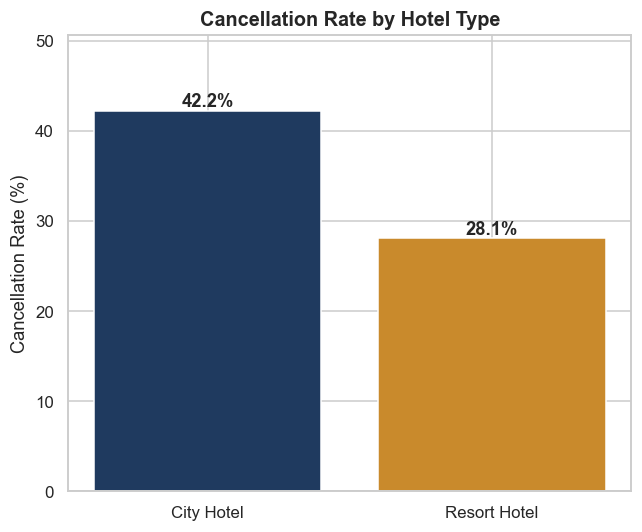

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(cancel_rate.index, cancel_rate.values,
               color=[HOTEL_COLORS[h] for h in cancel_rate.index])

for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:.1f}%", (bar.get_x() + bar.get_width()/2, height),
                ha="center", va="bottom", fontweight="bold")

ax.set_title("Cancellation Rate by Hotel Type")
ax.set_ylabel("Cancellation Rate (%)")
ax.set_ylim(0, max(cancel_rate.values) * 1.2)
plt.tight_layout()
plt.savefig("chart3_cancel_rate_hotel.png", dpi=150)
plt.show()

### Stay duration vs cancellation

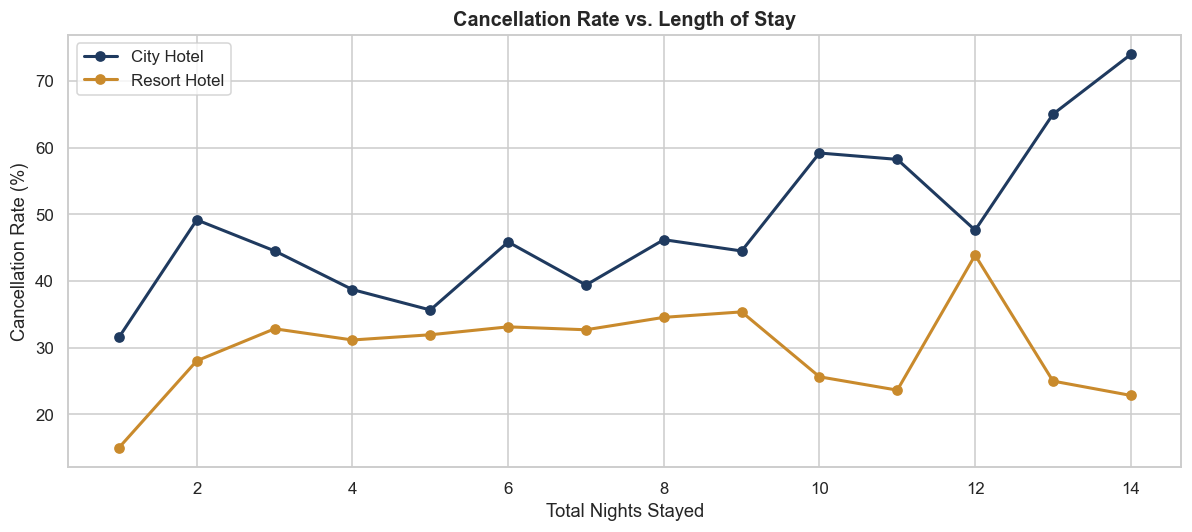

In [21]:
fig, ax = plt.subplots(figsize=(11, 5))

for hotel_type in ["City Hotel", "Resort Hotel"]:
    data = stay_cancel[stay_cancel["hotel"] == hotel_type]
    ax.plot(data["total_stay"], data["is_canceled"],
            marker="o", label=hotel_type, color=HOTEL_COLORS[hotel_type], linewidth=2)

ax.set_title("Cancellation Rate vs. Length of Stay")
ax.set_xlabel("Total Nights Stayed")
ax.set_ylabel("Cancellation Rate (%)")
ax.legend()
plt.tight_layout()
plt.savefig("chart4_cancel_vs_stay.png", dpi=150)
plt.show()

### Lead time vs cancellation

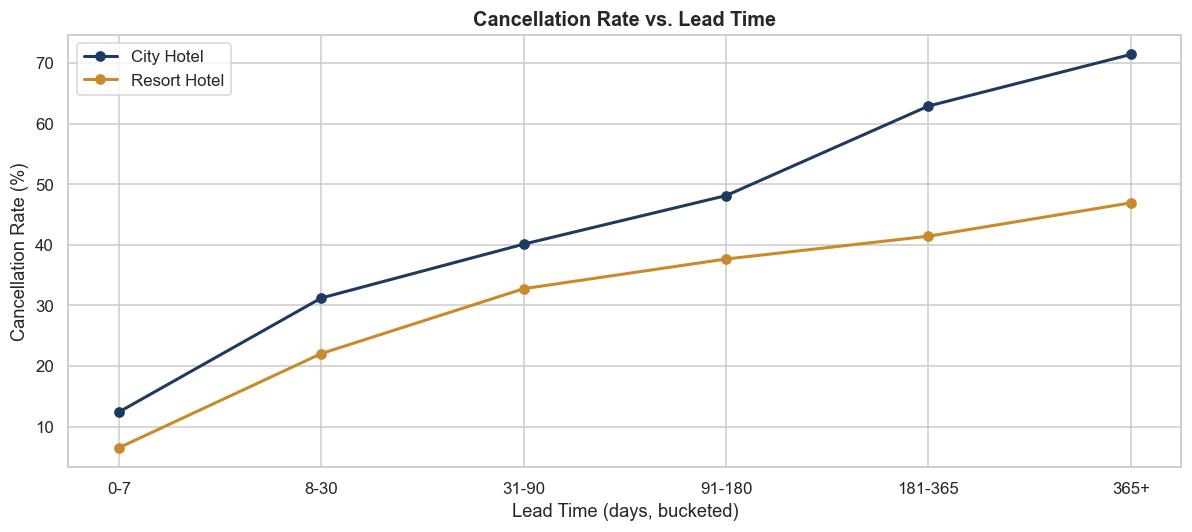

In [22]:
fig, ax = plt.subplots(figsize=(11, 5))

for hotel_type in ["City Hotel", "Resort Hotel"]:
    data = lead_cancel[lead_cancel["hotel"] == hotel_type]
    ax.plot(data["lead_time_bucket"], data["is_canceled"],
            marker="o", label=hotel_type, color=HOTEL_COLORS[hotel_type], linewidth=2)

ax.set_title("Cancellation Rate vs. Lead Time")
ax.set_xlabel("Lead Time (days, bucketed)")
ax.set_ylabel("Cancellation Rate (%)")
ax.legend()
plt.tight_layout()
plt.savefig("chart5_cancel_vs_leadtime.png", dpi=150)
plt.show()

In [23]:
import pandas as pd
import plotly.express as px
import streamlit as st

# Page ની basic settings — title, wide layout (professional look માટે)
st.set_page_config(
    page_title="Hotel Business Dashboard",
    page_icon="🏨",
    layout="wide"
)

# Professional colors (notebook જેવા જ, consistency માટે)
HOTEL_COLORS = {"City Hotel": "#1f3a5f", "Resort Hotel": "#c98a2c"}

@st.cache_data
def load_data():
    df = pd.read_csv("hotel_bookings_clean.csv")
    df["total_stay"] = df["stays_in_weekend_nights"] + df["stays_in_weekdays_nights"]
    return df

df = load_data()

2026-08-08 14:17:54.128 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 14:17:54.129 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-08-08 14:17:54.131 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-08-08 14:17:54.132 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 14:17:54.744 
  command:

    streamlit run C:\Users\MAGIC\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-08-08 14:17:54.745 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 14:17:54.745 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running 

In [24]:
st.title("🏨 Hotel Business Dashboard")
st.markdown("### Understanding Booking & Cancellation Behaviour (2017–2019)")
st.markdown("---")

2026-08-08 14:18:49.783 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 14:18:49.784 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 14:18:49.784 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 14:18:49.785 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 14:18:49.785 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 14:18:49.786 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 14:18:49.786 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 14:18:49.787 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [25]:
st.sidebar.header("Filters")

hotel_filter = st.sidebar.multiselect(
    "Hotel Type",
    options=df["hotel"].unique(),
    default=df["hotel"].unique()
)

year_filter = st.sidebar.multiselect(
    "Arrival Year",
    options=sorted(df["arrival_date_year"].unique()),
    default=sorted(df["arrival_date_year"].unique())
)

# Filter apply karo
df_filtered = df[(df["hotel"].isin(hotel_filter)) & (df["arrival_date_year"].isin(year_filter))]

2026-08-08 14:18:56.333 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 14:18:56.334 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 14:18:56.335 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 14:18:56.351 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 14:18:56.352 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 14:18:56.354 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 14:18:56.355 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-08 14:18:56.356 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [26]:
pip install streamlit plotly

Note: you may need to restart the kernel to use updated packages.


In [ ]:
cd 